<a href="https://colab.research.google.com/github/huyentramnguyen0509/Random-Forest-Based-Model/blob/main/Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
The machine learning model uses the Random Forest algorithm

=== [1] DATA CLEANING ===
Dataset size: 25044
=== [2] TRAINING MODEL ===
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      1929
           1       0.99      0.88      0.93      3080

    accuracy                           0.92      5009
   macro avg       0.92      0.93      0.92      5009
weighted avg       0.93      0.92      0.92      5009



Accuracy,0.9227
Precision,0.9887
Recall,0.8844
F1-score,0.9337
ROC-AUC,0.9855


Đã xuất file waf_report.html


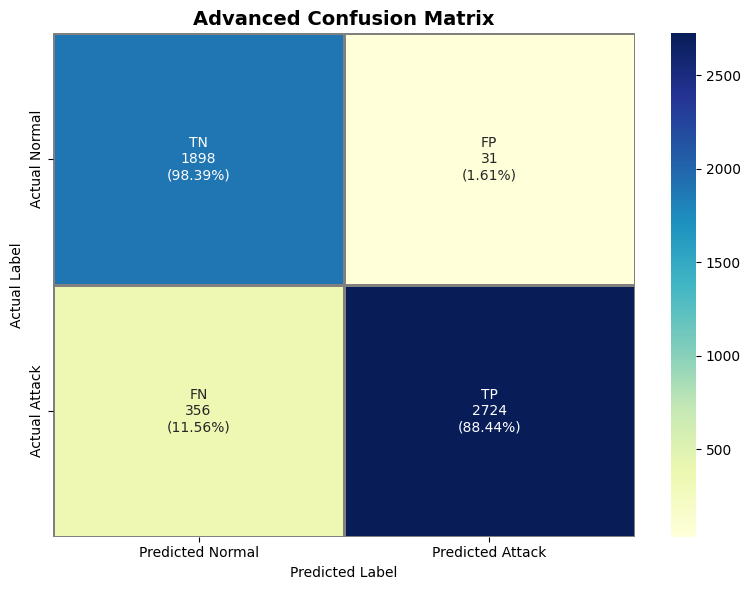


Additional Detection Metrics:
 True Positive Rate (TPR): 0.8844
 True Negative Rate (TNR): 0.9839
 False Positive Rate (FPR): 0.0161
 False Negative Rate (FNR): 0.1156


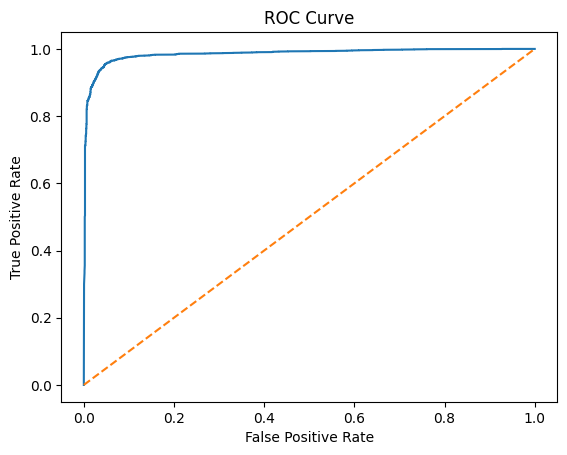

Model saved successfully!


In [2]:
import pandas as pd
import numpy as np
import urllib.parse
import html
import re
import joblib
from math import log2
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

def deep_decode(text):
    if not isinstance(text, str) or text == "":
        return "empty"
    try:
        for _ in range(2):
            text = urllib.parse.unquote(text)
            text = html.unescape(text)
        text = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', text)
        return text.lower()
    except:
        return str(text).lower()

def calculate_entropy(text):
    if not text:
        return 0
    counter = Counter(text)
    length = len(text)
    return -sum((count/length) * log2(count/length) for count in counter.values())

class StatisticalFeatures(BaseEstimator, TransformerMixin):

    def fit(self, x, y=None):
        return self

    def transform(self, posts):
        features = []

        for text in posts:
            length = len(text)
            entropy = calculate_entropy(text)

            special_chars = len(re.findall(r'[^a-zA-Z0-9\s]', text))
            digit_count = len(re.findall(r'\d', text))

            sqli_signs = text.count("'") + text.count("--") + text.count(";") + text.count("/*")
            xss_signs = text.count("<") + text.count(">") + text.count("script") + text.count("alert")
            path_signs = text.count("../") + text.count("etc/passwd")

            features.append([
                length,
                entropy,
                special_chars / (length + 1),
                digit_count / (length + 1),
                sqli_signs,
                xss_signs,
                path_signs
            ])

        return np.array(features)

def print_academic_metrics(acc, precision, recall, f1, roc):
    html_output = f"""
    <div style="
        background:white;
        border:2px solid #1f4e79;
        padding:30px;
        border-radius:10px;
        width:650px;
        font-family:Segoe UI, Arial;
        box-shadow:0 4px 12px rgba(0,0,0,0.08);
    ">
        <h2 style="text-align:center;color:#1f4e79;">
            Model Performance Evaluation
        </h2>

        <table style="width:100%; font-size:18px; border-collapse:collapse;">
            <tr><td><b>Accuracy</b></td><td align="right">{acc:.4f}</td></tr>
            <tr style="background:#f2f6fa;"><td><b>Precision</b></td><td align="right">{precision:.4f}</td></tr>
            <tr><td><b>Recall</b></td><td align="right">{recall:.4f}</td></tr>
            <tr style="background:#f2f6fa;"><td><b>F1-score</b></td><td align="right">{f1:.4f}</td></tr>
            <tr><td><b>ROC-AUC</b></td><td align="right" style="color:#1f4e79;"><b>{roc:.4f}</b></td></tr>
        </table>
    </div>
    """
    display(HTML(html_output))


def export_html_report(acc, precision, recall, f1, roc):
    html_content = f"""
    <html>
    <head>
        <title>WAF Performance Report</title>
    </head>
    <body style="font-family:Arial;background:#f4f6f9;padding:40px;">
        <div style="background:white;padding:30px;border-radius:10px;width:700px;margin:auto;">
            <h1 style="color:#1f4e79;text-align:center;">Web Application Firewall Report</h1>
            <hr>
            <ul style="font-size:18px;">
                <li><b>Accuracy:</b> {acc:.4f}</li>
                <li><b>Precision:</b> {precision:.4f}</li>
                <li><b>Recall:</b> {recall:.4f}</li>
                <li><b>F1-score:</b> {f1:.4f}</li>
                <li><b>ROC-AUC:</b> {roc:.4f}</li>
            </ul>
        </div>
    </body>
    </html>
    """

    with open("waf_report.html", "w", encoding="utf-8") as f:
        f.write(html_content)

    print("Đã xuất file waf_report.html")

def plot_advanced_confusion_matrix(y_test, y_pred):

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    labels = np.array([
        [
            f"TN\n{tn}\n({cm_percent[0,0]:.2f}%)",
            f"FP\n{fp}\n({cm_percent[0,1]:.2f}%)"
        ],
        [
            f"FN\n{fn}\n({cm_percent[1,0]:.2f}%)",
            f"TP\n{tp}\n({cm_percent[1,1]:.2f}%)"
        ]
    ])

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="YlGnBu",
        cbar=True,
        linewidths=1,
        linecolor="gray",
        xticklabels=["Predicted Normal", "Predicted Attack"],
        yticklabels=["Actual Normal", "Actual Attack"]
    )

    plt.title("Advanced Confusion Matrix", fontsize=14, fontweight="bold")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    print("\nAdditional Detection Metrics:")
    print(f" True Positive Rate (TPR): {tpr:.4f}")
    print(f" True Negative Rate (TNR): {tnr:.4f}")
    print(f" False Positive Rate (FPR): {fpr:.4f}")
    print(f" False Negative Rate (FNR): {fnr:.4f}")

def execute_pro_waf_system(csv_path):

    print("=== [1] DATA CLEANING ===")

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    df['URL'] = df['URL'].fillna('')
    df['content'] = df['content'].fillna('')

    df['processed_text'] = (df['URL'] + " " + df['content']).apply(deep_decode)

    df['classification'] = df['classification'].astype(str).str.lower()
    y = df['classification'].apply(lambda x: 0 if 'normal' in x or x == '0' else 1)

    df = df.drop_duplicates(subset=['processed_text'])

    X = df['processed_text'].values
    y = y.loc[df.index].values

    print(f"Dataset size: {len(X)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    features_union = FeatureUnion([
        ('manual_stats', StatisticalFeatures()),
        ('tfidf_nlp', TfidfVectorizer(
            analyzer='char',
            ngram_range=(2,4),
            max_features=1500
        ))
    ])

    model = Pipeline([
        ('features', features_union),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=35,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ])

    print("=== [2] TRAINING MODEL ===")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(classification_report(y_test, y_pred))

    print_academic_metrics(acc, precision, recall, f1, roc)
    export_html_report(acc, precision, recall, f1, roc)

    plot_advanced_confusion_matrix(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()

    joblib.dump(model, "final_model.pkl")
    print("Model saved successfully!")

    return model

if __name__ == "__main__":
    final_model = execute_pro_waf_system("csic_database.csv")